# Fine-Tune Gemma 3 270M — English Personal Assistant (SFT)
**Platform:** Kaggle (P100 (16 GB)) | **Model:** `google/gemma-3-270m-it` | **Dataset:** `HuggingFaceH4/ultrachat_200k`

### Kaggle Setup
1. `Settings → Accelerator → GPU P100`
2. `Settings → Internet → On`
3. `Add-ons → Secrets → New Secret → Name: HF_TOKEN → Value: your token`
4. Accept Gemma license: https://huggingface.co/google/gemma-3-270m-it
5. Run cells top to bottom

**Expected runtime: ~60–80 min on P100**


## Platform Config
### Kaggle P100 config
| Parameter | Value | Note |
|---|---|---|
| `TRAIN_SAMPLES` | 10,000 | Full planned dataset |
| `NUM_EPOCHS` | 3 | Full training run |
| `BATCH` | 4 | P100 has more headroom than T4 |
| `MAX_LENGTH` | 512 | Safe with gradient_checkpointing |


## 1. Install Dependencies


In [11]:
!pip install -q -U transformers datasets trl accelerate huggingface_hub rouge-score matplotlib


## 2. Imports + Hardware Check


In [12]:
import gc
import os
import random
import shutil
import time

import matplotlib.pyplot as plt
import torch
import transformers
import trl

print(f"[INFO] PyTorch      : {torch.__version__}")
print(f"[INFO] Transformers : {transformers.__version__}")
print(f"[INFO] TRL          : {trl.__version__}")

if torch.cuda.is_available():
    device    = torch.cuda.current_device()
    gpu_name  = torch.cuda.get_device_name(device)
    total_mem = torch.cuda.get_device_properties(device).total_memory / 1e9
    print(f"[INFO] GPU : {gpu_name} ({total_mem:.1f} GB VRAM)")
else:
    print("[WARN] No GPU detected!")


[INFO] PyTorch      : 2.9.0+cu126
[INFO] Transformers : 5.3.0
[INFO] TRL          : 0.29.0
[INFO] GPU : Tesla T4 (15.6 GB VRAM)


## 3. Hugging Face Authentication
Token read from Secrets — never hardcoded.


In [13]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# Reads HF_TOKEN from Kaggle Secrets (Add-ons → Secrets panel)
secrets  = UserSecretsClient()
hf_token = secrets.get_secret("HF_TOKEN")
login(token=hf_token)
print("[INFO] Logged in to Hugging Face")


[INFO] Logged in to Hugging Face


## 4. Configuration
All hyperparameters in one place. Only change `HF_USERNAME`.


In [26]:
# ── Model ───────────────────────────────────────────────────────────
MODEL_NAME = "google/gemma-3-270m-it"

# ── Dataset ─────────────────────────────────────────────────────────
DATASET_NAME  = "HuggingFaceH4/ultrachat_200k"
TRAIN_SAMPLES = 10000
TEST_SAMPLES  = 500
SEED          = 42

# ── Training hyperparameters ─────────────────────────────────────────
NUM_EPOCHS         = 3
TRAIN_BATCH_SIZE   = 4
EVAL_BATCH_SIZE    = 4
GRAD_ACCUM_STEPS   = 4
# Effective batch = 4 * 4 = 16
BASE_LEARNING_RATE = 2e-5
MAX_LENGTH         = 512
WARMUP_STEPS       = 50

# ── Paths ────────────────────────────────────────────────────────────
CHECKPOINT_DIR = "/kaggle/working/checkpoint_models"

# ── Hugging Face Hub ─────────────────────────────────────────────────
HF_USERNAME = "debojitbasak"
SUFFIX        = "v1"
MODEL_REPO_ID = f"{HF_USERNAME}/gemma3-270m-personal-assistant-{SUFFIX}"

# ── Memory ───────────────────────────────────────────────────────────
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

print(f"[INFO] Platform        : Kaggle (P100 (16 GB))")
print(f"[INFO] Train samples   : {TRAIN_SAMPLES}")
print(f"[INFO] Test samples    : {TEST_SAMPLES}")
print(f"[INFO] Epochs          : {NUM_EPOCHS}")
print(f"[INFO] Effective batch : {TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"[INFO] Learning rate   : {BASE_LEARNING_RATE}")
print(f"[INFO] Max length      : {MAX_LENGTH}")
print(f"[INFO] Model repo      : https://huggingface.co/{MODEL_REPO_ID}")


[INFO] Platform        : Kaggle (P100 (16 GB))
[INFO] Train samples   : 10000
[INFO] Test samples    : 500
[INFO] Epochs          : 3
[INFO] Effective batch : 16
[INFO] Learning rate   : 2e-05
[INFO] Max length      : 512
[INFO] Model repo      : https://huggingface.co/debojitbasak/gemma3-270m-personal-assistant-v1


## 5. Load & Curate the Dataset


In [15]:
from datasets import load_dataset

print(f"[INFO] Loading {DATASET_NAME} ...")
raw_dataset = load_dataset(DATASET_NAME)

train_full = raw_dataset["train_sft"]
test_full  = raw_dataset["test_sft"]
print(f"[INFO] Raw — train: {len(train_full)} | test: {len(test_full)}")

# ── Filter 1: min 2 turns ────────────────────────────────────────────
def has_min_turns(sample):
    return len(sample["messages"]) >= 2

train_f = train_full.filter(has_min_turns)
test_f  = test_full.filter(has_min_turns)

# ── Filter 2: max 8 turns ────────────────────────────────────────────
def has_max_turns(sample):
    return len(sample["messages"]) <= 8

train_f = train_f.filter(has_max_turns)
test_f  = test_f.filter(has_max_turns)
print(f"[INFO] After filters — train: {len(train_f)} | test: {len(test_f)}")

# ── Sample working subset ────────────────────────────────────────────
train_dataset = train_f.shuffle(seed=SEED).select(range(TRAIN_SAMPLES))
test_dataset  = test_f.shuffle(seed=SEED).select(range(TEST_SAMPLES))
print(f"[INFO] Final — train: {len(train_dataset)} | test: {len(test_dataset)}")


[INFO] Loading HuggingFaceH4/ultrachat_200k ...
[INFO] Raw — train: 207865 | test: 23110
[INFO] After filters — train: 190563 | test: 21188
[INFO] Final — train: 10000 | test: 500


## 6. Inspect the Data


[INFO] Turns  — avg: 5.9 | min: 2 | max: 8
[INFO] Tokens — avg: 1148 | max: 4057 | % under 512: 9.2%


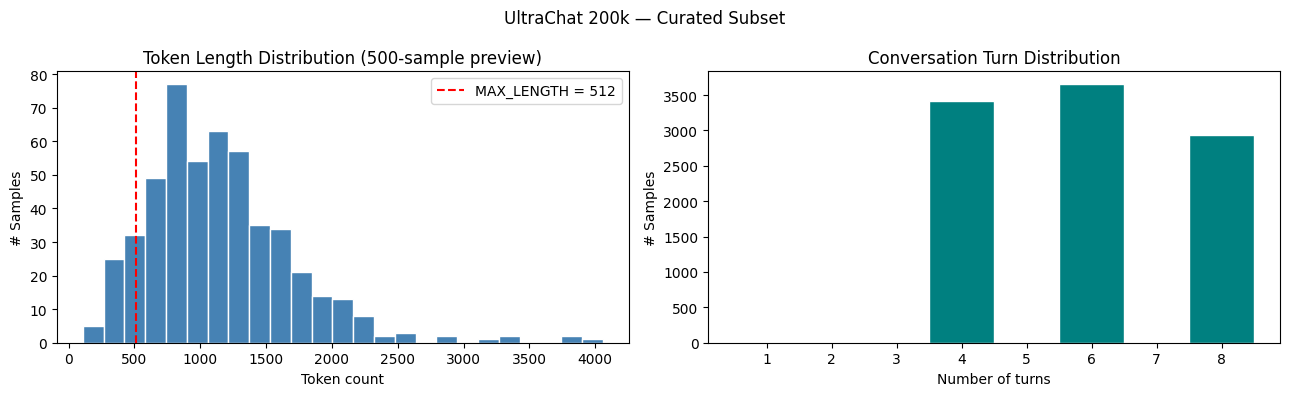


  SAMPLE CONVERSATIONS

  [0] Turns: 8
  USER        : How can businesses adopt environmentally-friendly practices to reduce waste and promote sustainabili...
  ASSISTANT   : 1. Reduce the use of paper: This can be achieved by encouraging electronic communications, using onl...
  USER        : I love the idea of green roofs! How can businesses implement them?
  ASSISTANT   : Businesses can implement green roofs by following these steps:  1. Assess the feasibility of a green...

  [1] Turns: 8
  USER        : Thanks to a slip of the tongue from a Republic Records executive during a recent interview and a ver...
  ASSISTANT   : There is no indication of what the collaboration between The Weeknd and Daft Punk will sound like ba...
  USER        : Can you provide me with a link to the article from Consequences Of Sound that mentions the slip of t...
  ASSISTANT   : Sure! Here is the link to the article from Consequences Of Sound: https://consequenceofsound.net/201...

  [2] Turns: 4
  USE

8592

In [16]:
from transformers import AutoTokenizer

tokenizer_stats = AutoTokenizer.from_pretrained(MODEL_NAME)

# Turn distribution
turn_counts  = [len(s["messages"]) for s in train_dataset]
print(f"[INFO] Turns  — avg: {sum(turn_counts)/len(turn_counts):.1f} | min: {min(turn_counts)} | max: {max(turn_counts)}")

# Token length (500-sample preview)
def count_tokens(s):
    return len(tokenizer_stats.encode(" ".join(m["content"] for m in s["messages"])))

token_counts = [count_tokens(s) for s in train_dataset.select(range(500))]
print(f"[INFO] Tokens — avg: {sum(token_counts)/len(token_counts):.0f} | max: {max(token_counts)} | % under {MAX_LENGTH}: {sum(1 for t in token_counts if t <= MAX_LENGTH)/len(token_counts):.1%}")

# Plots — keep in one cell so matplotlib renders correctly
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(token_counts, bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(MAX_LENGTH, color='red', linestyle='--',
                label=f'MAX_LENGTH = {MAX_LENGTH}')
axes[0].set_xlabel('Token count')
axes[0].set_ylabel('# Samples')
axes[0].set_title('Token Length Distribution (500-sample preview)')
axes[0].legend()

axes[1].hist(turn_counts, bins=range(1, max(turn_counts)+2),
             color='teal', edgecolor='white', align='left')
axes[1].set_xlabel('Number of turns')
axes[1].set_ylabel('# Samples')
axes[1].set_title('Conversation Turn Distribution')

plt.suptitle('UltraChat 200k — Curated Subset', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/data_distribution.png', dpi=150)
plt.show()

# Sample conversations
print("\n" + "="*70)
print("  SAMPLE CONVERSATIONS")
print("="*70)
for idx in [0, 1, 2]:
    s = train_dataset[idx]
    print(f"\n  [{idx}] Turns: {len(s['messages'])}")
    for msg in s["messages"][:4]:
        preview = msg["content"][:100].replace("\n", " ")
        dots    = "..." if len(msg["content"]) > 100 else ""
        print(f'  {msg["role"].upper():12s}: {preview}{dots}')

del tokenizer_stats
gc.collect()


## 7. Load the Base Model


In [17]:
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

print(f"[INFO] Loading tokenizer : {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"[INFO] Loading model     : {MODEL_NAME}")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager",
)
print(f"[INFO] dtype  : {model.dtype}")
print(f"[INFO] device : {model.device}")
print(f"[INFO] params : {sum(p.numel() for p in model.parameters()):,}")


[INFO] Loading tokenizer : google/gemma-3-270m-it
[INFO] Loading model     : google/gemma-3-270m-it


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

[INFO] dtype  : torch.bfloat16
[INFO] device : cuda:0
[INFO] params : 268,098,176


## 8. Baseline — Test Before Fine-Tuning
Save outputs now to compare against the fine-tuned model later.


In [18]:
from transformers import GenerationConfig

base_pipeline = pipeline("text-generation", model=model, tokenizer=tokenizer)


def pred_on_text(pipe, input_text, max_new_tokens=256):
    """Run inference. Returns (response_text, elapsed_seconds)."""
    gen_config = GenerationConfig(
        max_new_tokens=max_new_tokens,
        do_sample=False,           # greedy — deterministic
        repetition_penalty=1.1,    # avoids looping output
    )
    start     = time.time()
    raw       = pipe(text_inputs=[{"role": "user", "content": input_text}],
                     generation_config=gen_config)
    elapsed   = round(time.time() - start, 3)
    generated = raw[0]["generated_text"]
    output    = generated[-1]["content"] if isinstance(generated, list) else str(generated)
    return output, elapsed


baseline_prompts = [
    "Can you help me write a professional email to reschedule a meeting?",
    "What are three tips for staying productive while working from home?",
    "Explain what machine learning is in simple terms.",
    "Write a short to-do list for planning a birthday party.",
    "What should I consider when choosing a laptop for programming?",
]

baseline_results = {}
print("=" * 70)
print("  BASE MODEL — BEFORE FINE-TUNING")
print("=" * 70)
for prompt in baseline_prompts:
    output, elapsed = pred_on_text(base_pipeline, prompt)
    baseline_results[prompt] = {"output": output, "time": elapsed}
    print(f"\n  Prompt : {prompt}")
    print(f"  Output : {output[:300]}{'...' if len(output) > 300 else ''}")
    print(f"  Time   : {elapsed}s")
    print("-" * 70)


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


  BASE MODEL — BEFORE FINE-TUNING


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



  Prompt : Can you help me write a professional email to reschedule a meeting?
  Output : Subject: Reschedule of Meeting - [Meeting Topic]

Dear [Recipient Name],

I am writing to request a change in the subject line of our meeting scheduled for [Date] at [Time].

I would like to reschedule this meeting. Please let me know what time works best for you.

Thank you,

[Your Name]
  Time   : 2.838s
----------------------------------------------------------------------


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



  Prompt : What are three tips for staying productive while working from home?
  Output : Here are three tips for staying productive while working from home:

1.  **Establish a Dedicated Workspace:** Designate a specific area in your home solely for work, free from distractions like TV, noise, and personal devices. This helps to create a focused environment where you can concentrate on t...
  Time   : 6.027s
----------------------------------------------------------------------


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



  Prompt : Explain what machine learning is in simple terms.
  Output : Imagine you have a bunch of data, like pictures of cats and dogs. You want to learn how to tell the difference between them.

Machine Learning is basically teaching computers to **learn from data** without being explicitly programmed for every single situation. Instead, they use algorithms that help...
  Time   : 4.351s
----------------------------------------------------------------------


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



  Prompt : Write a short to-do list for planning a birthday party.
  Output : Okay, here's a short to-do list for planning your birthday party:

*   **Theme:** Choose a theme that suits the occasion and your friends!
*   **Guest List:** Decide on the number of guests you want to invite.
*   **Date & Time:** Consider availability and any specific requirements (e.g., dietary re...
  Time   : 10.276s
----------------------------------------------------------------------

  Prompt : What should I consider when choosing a laptop for programming?
  Output : Choosing the right laptop for programming depends heavily on your specific needs and goals. Here's a breakdown of factors to consider:

**1. Operating System (OS):**

*   **Windows:** The most popular choice, offering a wide range of features, customization options, and a vast ecosystem of software....
  Time   : 10.239s
----------------------------------------------------------------------


## 9. Fine-Tune with SFTTrainer

| Parameter | Value | Why |
|---|---|---|
| `TRAIN_BATCH_SIZE` | 4 | P100 headroom |
| `GRAD_ACCUM_STEPS` | 4 | Effective batch = 16 |
| `NUM_EPOCHS` | 3 | Full training run |
| `MAX_LENGTH` | 512 | Safe VRAM limit with gradient_checkpointing |
| `gradient_checkpointing` | True | Saves ~4 GB VRAM |
| `lr_scheduler_type` | cosine | Smooth decay → better generalisation |
| `warmup_steps` | 50 | Stable early training |
| `weight_decay` | 0.01 | L2 regularisation vs overfitting |
| `max_grad_norm` | 1.0 | Gradient clipping |
| `load_best_model_at_end` | True | Auto-reloads best checkpoint |


In [19]:
from trl import SFTConfig, SFTTrainer

torch_dtype = model.dtype

# ── Pre-apply chat template ───────────────────────────────────────────
# TRL 0.29+ needs a 'text' field with the pre-formatted string.
# remove_columns drops 'messages' so TRL takes the correct code path.
def apply_chat_template(sample):
    sample["text"] = tokenizer.apply_chat_template(
        sample["messages"], tokenize=False, add_generation_prompt=False)
    return sample

train_fmt = train_dataset.map(apply_chat_template,
                              remove_columns=train_dataset.column_names)
test_fmt  = test_dataset.map(apply_chat_template,
                             remove_columns=test_dataset.column_names)

print("[INFO] Chat template applied. Preview:")
print(train_fmt[0]["text"][:250])

sft_config = SFTConfig(
    output_dir=CHECKPOINT_DIR,
    max_length=MAX_LENGTH,
    dataset_text_field='text',     # prevents TRL from looking for prompt/completion
    packing=False,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    gradient_checkpointing=True,   # recomputes activations — saves ~4 GB VRAM
    optim='adamw_torch_fused',     # fused CUDA kernel — faster than standard AdamW
    learning_rate=BASE_LEARNING_RATE,
    lr_scheduler_type='cosine',    # smooth LR decay to ~0 by end of training
    warmup_steps=WARMUP_STEPS,     # ramp LR from 0 over first 50 steps
    weight_decay=0.01,             # mild L2 regularisation
    max_grad_norm=1.0,             # gradient clipping
    fp16=(torch_dtype == torch.float16),
    bf16=(torch_dtype == torch.bfloat16),
    logging_steps=10,
    save_strategy='epoch',
    eval_strategy='epoch',
    metric_for_best_model='eval_loss',
    load_best_model_at_end=True,   # reloads best checkpoint after training
    push_to_hub=False,
    report_to='none',
    seed=SEED,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_fmt,
    eval_dataset=test_fmt,
    processing_class=tokenizer,
)

print("\n[INFO] Starting fine-tuning...")
training_start  = time.time()
training_output = trainer.train()
training_time   = round(time.time() - training_start, 1)

print(f"\n[INFO] Done in {training_time}s ({training_time/60:.1f} min)")
print(f"[INFO] Train loss : {training_output.metrics.get('train_loss', 'N/A'):.4f}")


[INFO] Chat template applied. Preview:
<bos><start_of_turn>user
How can businesses adopt environmentally-friendly practices to reduce waste and promote sustainability?<end_of_turn>
<start_of_turn>model
1. Reduce the use of paper: This can be achieved by encouraging electronic communicatio


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2, 'pad_token_id': 0}.



[INFO] Starting fine-tuning...


Epoch,Training Loss,Validation Loss
1,1.934457,1.921978
2,1.911954,1.910908
3,1.866073,1.910895


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].



[INFO] Done in 9050.7s (150.8 min)
[INFO] Train loss : 1.9508


## 10. Loss Curves
- **Healthy:** both curves fall and stay close
- **Overfitting:** eval rises while train keeps falling
- **Underfitting:** both still high at end


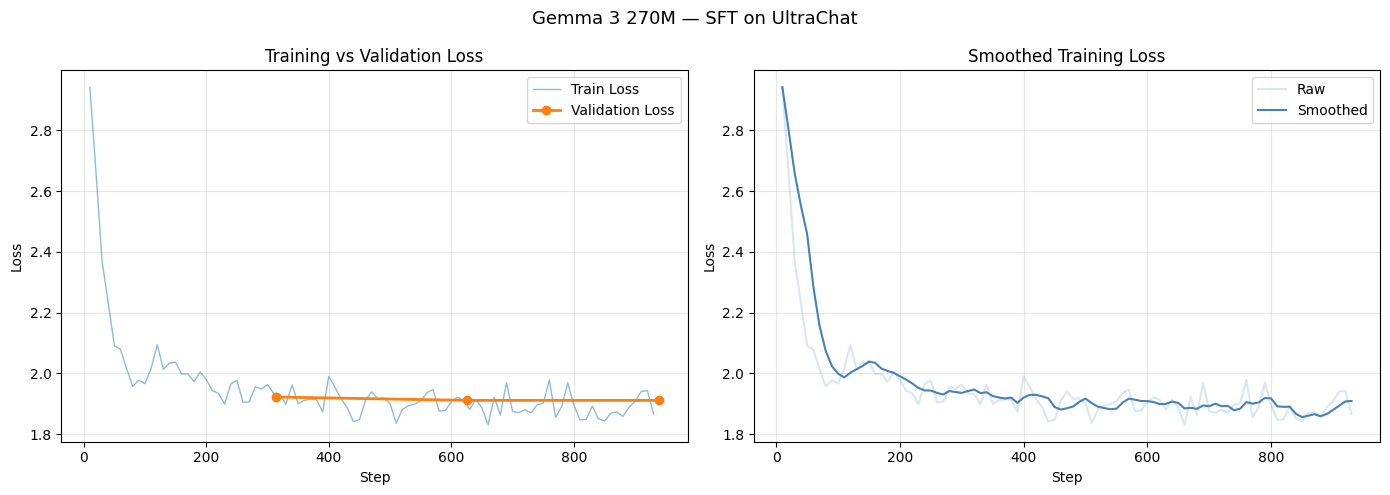

[INFO] Best eval loss  : 1.9109 (epoch 3)
[INFO] Final eval loss : 1.9109
[INFO] Final train loss: 1.8661


In [20]:
log_history  = trainer.state.log_history
train_losses = [l['loss']      for l in log_history if 'loss'      in l and 'eval_loss' not in l]
train_steps  = [l['step']      for l in log_history if 'loss'      in l and 'eval_loss' not in l]
eval_losses  = [l['eval_loss'] for l in log_history if 'eval_loss' in l]
eval_steps   = [l['step']      for l in log_history if 'eval_loss' in l]

# Rolling average to smooth noisy step-level loss
window   = max(1, len(train_losses) // 20)
smoothed = [
    sum(train_losses[max(0,i-window):i+1]) / len(train_losses[max(0,i-window):i+1])
    for i in range(len(train_losses))
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_steps, train_losses, label='Train Loss',      alpha=0.5, linewidth=1)
axes[0].plot(eval_steps,  eval_losses,  label='Validation Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Step') ; axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend() ; axes[0].grid(True, alpha=0.3)

axes[1].plot(train_steps, train_losses, alpha=0.2, color='steelblue', label='Raw')
axes[1].plot(train_steps, smoothed,     color='steelblue',            label='Smoothed')
axes[1].set_xlabel('Step') ; axes[1].set_ylabel('Loss')
axes[1].set_title('Smoothed Training Loss')
axes[1].legend() ; axes[1].grid(True, alpha=0.3)

plt.suptitle('Gemma 3 270M — SFT on UltraChat', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/loss_curves.png', dpi=150)
plt.show()

if eval_losses:
    best_ep = eval_losses.index(min(eval_losses)) + 1
    print(f"[INFO] Best eval loss  : {min(eval_losses):.4f} (epoch {best_ep})")
    print(f"[INFO] Final eval loss : {eval_losses[-1]:.4f}")
print(f"[INFO] Final train loss: {train_losses[-1]:.4f}")


## 11. Save the Model


In [21]:
trainer.save_model()
print(f"[INFO] Saved to: {CHECKPOINT_DIR}")

for item in os.listdir(CHECKPOINT_DIR):
    if item.startswith('checkpoint-'):
        shutil.rmtree(os.path.join(CHECKPOINT_DIR, item))
        print(f"[INFO] Removed: {item}")

for fname in sorted(os.listdir(CHECKPOINT_DIR)):
    mb = os.path.getsize(os.path.join(CHECKPOINT_DIR, fname)) / 1e6
    print(f"  {fname:45s}  {mb:>7.1f} MB")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Saved to: /kaggle/working/checkpoint_models
[INFO] Removed: checkpoint-626
[INFO] Removed: checkpoint-313
[INFO] Removed: checkpoint-939
  README.md                                          0.0 MB
  chat_template.jinja                                0.0 MB
  config.json                                        0.0 MB
  generation_config.json                             0.0 MB
  model.safetensors                                536.2 MB
  tokenizer.json                                    33.4 MB
  tokenizer_config.json                              0.0 MB
  training_args.bin                                  0.0 MB


## 12. Reload Fine-Tuned Model
Free GPU memory, then clean reload from checkpoint.


In [22]:
del model, trainer, base_pipeline
gc.collect()
torch.cuda.empty_cache()
print("[INFO] GPU memory freed")

print(f"[INFO] Loading fine-tuned model...")
ft_model     = AutoModelForCausalLM.from_pretrained(
    CHECKPOINT_DIR, dtype="auto", device_map="auto", attn_implementation="eager")
ft_tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT_DIR)
ft_pipe      = pipeline("text-generation", model=ft_model, tokenizer=ft_tokenizer)
print("[INFO] Fine-tuned model ready")


[INFO] GPU memory freed
[INFO] Loading fine-tuned model...


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

[INFO] Fine-tuned model ready


## 13. Quantitative Evaluation — ROUGE-L
Longest Common Subsequence overlap. Range 0→1, higher = better.


[INFO] Evaluating on 100 samples...


ROUGE-L:   0%|          | 0/100 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



[INFO] ROUGE-L mean   : 0.215
[INFO] ROUGE-L median : 0.204
[INFO] Score > 0.3    : 11.0%
[INFO] Score > 0.5    : 1.0%


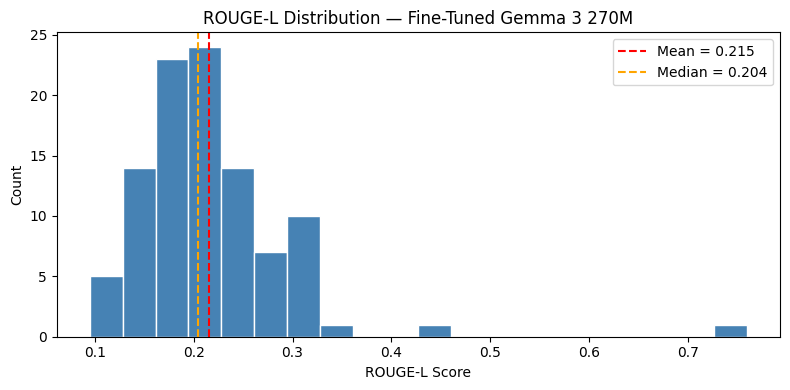

In [23]:
from tqdm.auto import tqdm
from rouge_score import rouge_scorer as rs_lib

scorer    = rs_lib.RougeScorer(['rougeL'], use_stemmer=True)
eval_data = list(test_dataset.select(range(100)))
results   = []

print(f"[INFO] Evaluating on {len(eval_data)} samples...")
for row in tqdm(eval_data, desc='ROUGE-L'):
    msgs          = row["messages"]
    last_u        = max(i for i, m in enumerate(msgs) if m["role"] == "user")
    reference     = msgs[last_u+1]['content'] if last_u+1 < len(msgs) else ''
    if not reference: continue
    predicted, _  = pred_on_text(ft_pipe, msgs[last_u]["content"])
    results.append(scorer.score(reference, predicted)['rougeL'].fmeasure)

total  = len(results)
mean_r = sum(results) / total
med_r  = sorted(results)[total // 2]

print(f"\n[INFO] ROUGE-L mean   : {mean_r:.3f}")
print(f"[INFO] ROUGE-L median : {med_r:.3f}")
print(f"[INFO] Score > 0.3    : {sum(1 for s in results if s > 0.3)/total:.1%}")
print(f"[INFO] Score > 0.5    : {sum(1 for s in results if s > 0.5)/total:.1%}")

plt.figure(figsize=(8, 4))
plt.hist(results, bins=20, color='steelblue', edgecolor='white')
plt.axvline(mean_r, color='red',    linestyle='--', label=f'Mean = {mean_r:.3f}')
plt.axvline(med_r,  color='orange', linestyle='--', label=f'Median = {med_r:.3f}')
plt.xlabel('ROUGE-L Score') ; plt.ylabel('Count')
plt.title('ROUGE-L Distribution — Fine-Tuned Gemma 3 270M')
plt.legend() ; plt.tight_layout()
plt.savefig('/kaggle/working/rouge_distribution.png', dpi=150)
plt.show()


## 14. Qualitative Evaluation — Before vs After


In [24]:
print("=" * 70)
print("  BEFORE vs AFTER FINE-TUNING")
print("=" * 70)
for prompt in baseline_prompts:
    before         = baseline_results[prompt]['output']
    after, elapsed = pred_on_text(ft_pipe, prompt)
    print(f"\n  PROMPT : {prompt}")
    print(f"  BEFORE : {before[:300]}{"..." if len(before) > 300 else ""}")
    print(f"  AFTER  : {after[:300]}{"..." if len(after) > 300 else ""}")
    print(f"  [{elapsed}s]")
    print("=" * 70)


  BEFORE vs AFTER FINE-TUNING

  PROMPT : Can you help me write a professional email to reschedule a meeting?
  BEFORE : Subject: Reschedule of Meeting - [Meeting Topic]

Dear [Recipient Name],

I am writing to request a change in the subject line of our meeting scheduled for [Date] at [Time].

I would like to reschedule this meeting. Please let me know what time works best for you.

Thank you,

[Your Name]
  AFTER  : Subject: Rescheduling Meeting - [Your Name]

Dear [Recipient Name],

I hope this email finds you well. I would like to reschedule our meeting for [Date and Time]. Please let me know if there is any reason why it needs to be rescheduled, or if you have any other alternative dates that work better for...
  [4.623s]

  PROMPT : What are three tips for staying productive while working from home?
  BEFORE : Here are three tips for staying productive while working from home:

1.  **Establish a Dedicated Workspace:** Designate a specific area in your home solely for work, free f

## 15. Upload to Hugging Face Hub


In [27]:
from huggingface_hub import HfApi, create_repo

api = HfApi()
print(f"[INFO] Creating repo: {MODEL_REPO_ID}")
create_repo(repo_id=MODEL_REPO_ID, repo_type='model', exist_ok=True)

print("[INFO] Uploading (~540 MB)...")
api.upload_folder(
    folder_path=CHECKPOINT_DIR,
    repo_id=MODEL_REPO_ID,
    repo_type='model',
)
print(f"[INFO] Live at: https://huggingface.co/{MODEL_REPO_ID}")


[INFO] Creating repo: debojitbasak/gemma3-270m-personal-assistant-v1
[INFO] Uploading (~540 MB)...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

[INFO] Live at: https://huggingface.co/debojitbasak/gemma3-270m-personal-assistant-v1


## 16. Summary


In [30]:
print(f"""
{'='*65}
  Fine-Tuning Complete!
{'='*65}
  Platform         : Kaggle (P100 (16 GB))
  Model            : {MODEL_NAME}
  Dataset          : {DATASET_NAME}
  Train samples    : {TRAIN_SAMPLES}
  Epochs           : {NUM_EPOCHS}
  Effective batch  : {TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS}
  Max length       : {MAX_LENGTH}
  Training time    : {training_time}s ({training_time/60:.1f} min)

  Best eval loss   : {min(eval_losses):.4f}
  ROUGE-L mean     : {mean_r:.3f}

  Model uploaded   : https://huggingface.co/{MODEL_REPO_ID}
{'='*65}
""")



  Fine-Tuning Complete!
  Platform         : Kaggle (P100 (16 GB))
  Model            : google/gemma-3-270m-it
  Dataset          : HuggingFaceH4/ultrachat_200k
  Train samples    : 10000
  Epochs           : 3
  Effective batch  : 16
  Max length       : 512
  Training time    : 9050.7s (150.8 min)

  Best eval loss   : 1.9109
  ROUGE-L mean     : 0.215

  Model uploaded   : https://huggingface.co/debojitbasak/gemma3-270m-personal-assistant-v1

